# Can we fit $Re[\mathcal{H}]$ Using DNNs at a Single Kinematic Point Using the KM15/BKM10 Formalism for the Cross-Section?

## (1): Initializing Requisite Code/Settings:

### (1.1): Import Libraries:

In [1]:
import glob
from sklearn.model_selection import train_test_split
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from iminuit import Minuit
from scipy.integrate import quad
import gepard as g
from gepard.fits import th_KM15
from gepard.bmk import BM10
from bkm10_lib.core import DifferentialCrossSection
from bkm10_lib.inputs import BKM10Inputs
from bkm10_lib.cff_inputs import CFFInputs

# tf.keras.config.set_floatx('float64')

### (1.2): Matplotlib Plotting Aesthetics:

In [2]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
})

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 8.5
plt.rcParams['xtick.major.width'] = 0.5
plt.rcParams['xtick.minor.size'] = 2.5
plt.rcParams['xtick.minor.width'] = 0.5
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['ytick.major.size'] = 8.5
plt.rcParams['ytick.major.width'] = 0.5
plt.rcParams['ytick.minor.size'] = 2.5
plt.rcParams['ytick.minor.width'] = 0.5
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['ytick.right'] = True

## (2): Generating Pseudodata:

### (2.0): Data Collection Definitions:

In [3]:
VERSION_NUMBER = 1
MINOR_NUMBER = 1
MAJOR_MINOR_NUMBER = f"v{VERSION_NUMBER}_{MINOR_NUMBER}"

### (2.1): Defining the Kinematic Point:

In [4]:
TEST_BEAM_ENERGY = 5.75
TEST_Q_SQUARED = 1.82
TEST_X_BJORKEN = 0.34
TEST_T_VALUE = -.17

# these values come later *and* are derived from the values above:
# see [this Mathematica notebook](https://github.com/Woofmagic/BKM10_Spin_Polarized/blob/main/mathematica/bkm10_test.nb)
TEST_EP = 0.47293561004973345
TEST_Y = 0.49609612355928445
TEST_XI = 0.19906188837146524
TEST_T_MIN = -0.13551824472915253
TEST_T_PRIME = -0.034481755270847486
TEST_K_TILDE = 0.1592415651944438
TEST_K = 0.08492693191323883
TEST_FE = 0.6511853266961825
TEST_FG = 1.8186612105254523
TEST_F2 = 1.1137103937669304
TEST_F1 = 0.7049508167585219

TEST_REAL_CFF_H = -0.897
TEST_REAL_CFF_HT = 2.444
TEST_REAL_CFF_E = -0.541
TEST_REAL_CFF_ET = 2.207 
TEST_IM_CFF_H = 2.421
TEST_IM_CFF_HT = 1.131
TEST_IM_CFF_E = 0.903
TEST_IM_CFF_ET = 5.383

## WW-relations are on!!
TEST_REAL_CFF_H_EFF = -1.4961696451186222
TEST_REAL_CFF_HT_EFF = 4.0765201924971155
TEST_REAL_CFF_E_EFF = -0.9023721048039851
TEST_REAL_CFF_ET_EFF = 3.6812111558269773
TEST_IM_CFF_H_EFF = 4.038156868263304
TEST_IM_CFF_HT_EFF = 1.8864747699321758
TEST_IM_CFF_E_EFF = 1.5061774688317902
TEST_IM_CFF_ET_EFF = 8.978685841330593

### (2.2): Defining the Azimuthal Range:

In [5]:
STARTING_PHI_VALUE_IN_DEGREES = 0
ENDING_PHI_VALUE_IN_DEGREES = 360
NUMBER_OF_PHI_POINTS = 15
phi_array_in_degrees = np.linspace(
    start = STARTING_PHI_VALUE_IN_DEGREES,
    stop = ENDING_PHI_VALUE_IN_DEGREES,
    num = NUMBER_OF_PHI_POINTS)
phi_array_in_radians = [np.radians(degree_value) for degree_value in phi_array_in_degrees]

### (2.3): Use the KM15 Model of $Re[\mathcal{H}]$ and $Im[\mathcal{H}]$ to Generate a True Value:

In [6]:
test_datapoints = [g.DataPoint(
    xB = TEST_X_BJORKEN, t = TEST_T_VALUE, Q2 = TEST_Q_SQUARED, phi = fixed_phi,
    process = "ep2epgamma", exptype = 'fixed target',
    in1energy = TEST_BEAM_ENERGY, in1charge = -1, in1polarization = +1,
    observable = 'XS',
    fname = 'Trento') for fixed_phi in phi_array_in_radians]

#### (2.3.1): Check out the Length of the Datapoint Array:

In [7]:
len(test_datapoints) == len(phi_array_in_radians)

True

### (2.4): Evaluate 

In [8]:
real_h_values = [th_KM15.ReH(datapoint) for datapoint in test_datapoints]
imag_h_values = [th_KM15.ImH(datapoint) for datapoint in test_datapoints]

#### (2.4.1): Check out the Length of the CFF Data Array:

In [9]:
print(len(real_h_values) == len(test_datapoints))
print(len(imag_h_values) == len(test_datapoints))

True
True


#### (2.4.2): See Some Values in the CFF Arrays:

In [10]:
real_h_values

[-2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387]

### (2.5): Use the [BKM10 Library](https://pypi.org/project/bkm10/) to Predict the Cross-Section

#### (2.5.1): Define the CFF Values --- **Very Important!!**

Note that at the specific kinematic settings of
```python
TEST_BEAM_ENERGY = 5.75
TEST_Q_SQUARED = 1.82
TEST_X_BJORKEN = 0.34
TEST_T_VALUE = -.17
```
one can use the following configuration of the 8 CFFs according to [Higher-order kinematical effects in deeply virtual Compton scattering](https://link.springer.com/article/10.1007/JHEP12(2021)103) --- See Table 1
```python
CFF_H = complex(-0.897, 2.421)
CFF_H_TILDE = complex(2.444, 1.131)
CFF_E = complex(-0.541, 0.903)
CFF_E_TILDE = complex(2.207, 5.383)
```

So, **please understand** that what we will do is **change only the `CFF_H` values** in accordance with what the KM15 model predicts and leave **all the other CFFs the same**!

In [11]:
CFF_H = complex(real_h_values[0], imag_h_values[0])
CFF_H_TILDE = complex(2.444, 1.131)
CFF_E = complex(-0.541, 0.903)
CFF_E_TILDE = complex(2.287, 5.383)

#### (2.5.2): Use the BKM10 Library to Evaluate the Cross-Section as a Function of $\phi$

In [12]:
cross_section = DifferentialCrossSection(
    configuration = {
        "kinematics": BKM10Inputs(
            lab_kinematics_k = TEST_BEAM_ENERGY,
            squared_Q_momentum_transfer = TEST_Q_SQUARED,
            x_Bjorken = TEST_X_BJORKEN,
            squared_hadronic_momentum_transfer_t = TEST_T_VALUE),
        "cff_inputs": CFFInputs(
            compton_form_factor_h = CFF_H,
            compton_form_factor_h_tilde = CFF_H_TILDE,
            compton_form_factor_e = CFF_E,
            compton_form_factor_e_tilde = CFF_E_TILDE),
        "target_polarization": 0.0,
        "lepton_beam_polarization": 0.0,
        "using_ww": True
    },
    verbose = False,
    debugging = False)

bkm10_cross_sections = cross_section.compute_cross_section(phi_array_in_radians).real

#### (2.5.3): Check Out the Cross-Section

Text(0, 0.5, '$d^{4}\\sigma$')

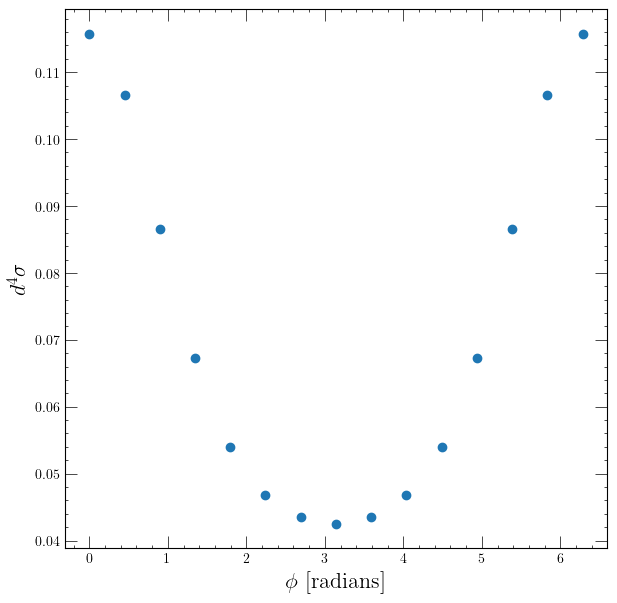

In [13]:
cross_section_fig, cross_section_axes = plt.subplots(1, figsize = (7, 7))
cross_section_axes.scatter(
    phi_array_in_radians,
    bkm10_cross_sections)
cross_section_axes.set_xlabel(r"$\phi$ [radians]", fontsize = 16)
cross_section_axes.set_ylabel(r"$d^{4}\sigma$", fontsize = 16)


### (2.6): Piece Together Fixed Kinematic Settings, Varying Phi Data, and CFF Data into Pandas DataFrame:

In [14]:
test_dataframe = pd.DataFrame({
    "set": 1,
    "k": TEST_T_VALUE,
    "q_squared": TEST_Q_SQUARED,
    "x_b": TEST_X_BJORKEN,
    "t": TEST_T_VALUE,
    "phi": phi_array_in_radians,
    "cross_section": bkm10_cross_sections,
    "Re[H]": real_h_values,
    "Im[H]": imag_h_values
})

### (2.6.1): Checking Out the DataFrame with the Pseudodata:

In [15]:
test_dataframe

,set,k,q_squared,x_b,t,phi,cross_section,Re[H],Im[H]
0,1,-0.17,1.82,0.34,-0.17,0.000000,0.115764,-2.449018,3.481649
1,1,-0.17,1.82,0.34,-0.17,0.448799,0.106668,-2.449018,3.481649
2,1,-0.17,1.82,0.34,-0.17,0.897598,0.086557,-2.449018,3.481649
3,1,-0.17,1.82,0.34,-0.17,1.346397,0.067217,-2.449018,3.481649
4,1,-0.17,1.82,0.34,-0.17,1.795196,0.054044,-2.449018,3.481649
5,1,-0.17,1.82,0.34,-0.17,2.243995,0.046771,-2.449018,3.481649
6,1,-0.17,1.82,0.34,-0.17,2.692794,0.043447,-2.449018,3.481649
7,1,-0.17,1.82,0.34,-0.17,3.141593,0.042522,-2.449018,3.481649
8,1,-0.17,1.82,0.34,-0.17,3.590392,0.043447,-2.449018,3.481649
9,1,-0.17,1.82,0.34,-0.17,4.039191,0.046771,-2.449018,3.481649


## (3): Data Preprocessing:

### (3.1): Define What Becomes the $x$ and $y$ Data:

**Important**: Define here what you want to train on!

In [16]:
x = test_dataframe[["t", "x_b", "phi"]]
y = test_dataframe["cross_section"]

### (3.2): Train-Test Split Here:

In [17]:
_NUMBER_OF_TESTING_SAMPLES = 5

x_training, x_validation, y_training, y_validation = train_test_split(
    x,
    y,
    test_size = _NUMBER_OF_TESTING_SAMPLES,
    shuffle = True)

## (4): DNN Model Definitions:

### (4.1): Static Quantities Used in Loss Computation:

**Important**: `Q_SQUARED` ($Q^{2}$) and `_LAB_K_BEAM` ($k$) are treated as fixed the ENTIRE TIME during training.

#### (4.1.1): Statics in Loss Computation:

In [18]:
_MASS_OF_PROTON_IN_GEV = 0.93827208816
_ELECTRIC_FORM_FACTOR_CONSTANT = 0.710649
_PROTON_MAGNETIC_MOMENT = 2.79284734463

### (4.1.2): Important Statics (Kinematics)

`_Q_SQUARED` and `_LAB_K_BEAM` are **here**!!

In [19]:
_LAB_K_BEAM = test_dataframe["k"].iloc[0]
_Q_SQUARED = test_dataframe["q_squared"].iloc[0]

#### (4.1.2.1): Check Out the Static Quantities in the Kinematics:

Why did we use this `.iloc[0]`? Because we knew that the dataset doesn't change across a single kinematic bin; effectively, the dataset depicts the CFFs as functions of $\phi$ only. We could have chosen any one of the indices of the DF as an index, and it would have pulled out the same value for `_LAB_K_BEAM` and `_Q_SQUARED`. Proof is below:

In [20]:
print(f"Is it invariant under index? {test_dataframe["q_squared"].iloc[0] == test_dataframe["q_squared"].iloc[5]}")
print(f"Is it invariant under index? {test_dataframe["k"].iloc[0] == test_dataframe["k"].iloc[10]}")

Is it invariant under index? True
Is it invariant under index? True


In [21]:
print(f"Fixed k is: {_LAB_K_BEAM}")
print(f"Fixed Q^2 is: {_Q_SQUARED}")

Fixed k is: -0.17
Fixed Q^2 is: 1.82


### (4.2): Relevant Functions in Loss Computation:

These equations below come from the HERMES paper that the DNN one took their data from. I am assuming the DNN paper also used the equations in the HERMES paper to compute the BSA and BCA.

#### (4.2.1): Kinematic Stuff:

In [22]:
def compute_epsilon(xb, q_squared):
    return tf.divide(2. * xb * _MASS_OF_PROTON_IN_GEV, tf.sqrt(q_squared))

def compute_y(k_beam, q_squared, ep):
    return tf.sqrt(q_squared) / (ep * k_beam)

def compute_skewness(xb, t, q_squared):
    return xb * (1. + (t / (2. * q_squared))) / (2. - xb + (xb * t / q_squared))

def compute_t_min(xb, q_squared, ep):
    return -1. * q_squared * ((2. * (1. - xb) * (1. - tf.sqrt(1. + ep**2))) + ep**2) / ((4. * xb * (1. - xb)) + ep**2)

def compute_t_prime(t, tmin):
    return (t-tmin)

def compute_k_tilde(xb, q_squared, t, tmin, ep):
    return tf.sqrt(tmin - t) * tf.sqrt(((1. - xb) * tf.sqrt((1. + ep**2))) + (((tmin - t) * (ep**2 + (4. * (1. - xb) * xb))) / (4. * q_squared)))

def compute_k(q_squared, y, ep, k_tilde):
    return tf.sqrt(((1. - y + (ep**2 * y**2 / 4.)) / q_squared)) * k_tilde

def compute_k_dot_delta(q_squared, xb, t, phi, ep, y, k):
    return (-1.*q_squared / (2.*y*(1.+ep**2))) * (1. + ((2.*k*tf.cos(tf.pi - phi)) - ((t / q_squared)*(1.-(xb * (2. - y)) + (y * ep**2 / 2.))) + (y * ep**2 / 2.)))

def prop_1(q_squared, kdd):
    return (1. + (2. * (kdd / q_squared)))

def prop_2(q_squared, t, kdd):
    return ((-2. * (kdd / q_squared)) + (t / q_squared))

def compute_fe(t):
    return tf.divide(1., tf.square(1. - tf.divide(t, _ELECTRIC_FORM_FACTOR_CONSTANT)))

def compute_fg(fe):
    return _PROTON_MAGNETIC_MOMENT * fe

def compute_f2(t, fe, fg):
    tau = tf.divide(-1. * t, 4. * tf.square(_MASS_OF_PROTON_IN_GEV))
    numerator = fg - fe
    denominator = 1. + tau
    return tf.divide(numerator, denominator)

def compute_f1(fg, f2):
    return fg - f2

#### (4.2.1): BH Coefficients:

In [23]:
def bh_unp_c0(
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float,
    k: float,
    f1: float, 
    f2: float):
    first_line = 8. * k**2 * (((2. + 3. * ep**2) * (f1**2 - (t * f2**2 / (4. * _MASS_OF_PROTON_IN_GEV**2))) / (t / q_sq)) + (2. * xb**2 * (f1 + f2)**2))
    second_line_first_part = (2. + ep**2) * ((4. * xb**2 * _MASS_OF_PROTON_IN_GEV**2 / t) * (1. + (t / q_sq))**2 + 4. * (1 - xb) * (1. + (xb * (t / q_sq)))) * (f1**2 - (t * f2**2 / (4. * _MASS_OF_PROTON_IN_GEV**2)))
    second_line_second_part = 4. * xb**2 * (xb + (1. - xb + (ep**2 / 2.)) * (1 - (t / q_sq))**2 - xb * (1. - 2. * xb) * (t / q_sq)**2) * (f1 + f2)**2
    second_line = (2. - y)**2 * (second_line_first_part + second_line_second_part)
    third_line = 8. * (1. + ep**2) * (1. - y - (ep**2 * y**2 / 4.)) * (2. * ep**2 * (1 - (t / (4. * _MASS_OF_PROTON_IN_GEV**2))) * (f1**2 - (t * f2**2 / (4. * _MASS_OF_PROTON_IN_GEV**2))) - xb**2 * (1 - (t / q_sq))**2 * (f1 + f2)**2)
    c0_unpolarized_bh = first_line + second_line + third_line
    return c0_unpolarized_bh

def bh_unp_c1(
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float,
    k: float,
    f1: float, 
    f2: float) -> float:
    addition_of_form_factors_squared = (f1 + f2)**2
    weighted_combination_of_form_factors = f1**2 - ((t / (4. * _MASS_OF_PROTON_IN_GEV**2)) * f2**2)
    first_line_first_part = ((4. * xb**2 * _MASS_OF_PROTON_IN_GEV**2 / t) - 2. * xb - ep**2) * weighted_combination_of_form_factors
    first_line_second_part = 2. * xb**2 * (1. - (1. - 2. * xb) * (t / q_sq)) * addition_of_form_factors_squared
    c1_unpolarized_bh = 8. * k * (2. - y) * (first_line_first_part + first_line_second_part)
    return c1_unpolarized_bh

def bh_unp_c2( 
    xb: float, 
    t: float,
    k: float,
    f1: float, 
    f2: float) -> float:
    addition_of_form_factors_squared = (f1 + f2)**2
    weighted_combination_of_form_factors = f1**2 - ((t/ (4. * _MASS_OF_PROTON_IN_GEV**2)) * f2**2)
    first_part_of_contribution = (4. * _MASS_OF_PROTON_IN_GEV**2 / t) * weighted_combination_of_form_factors
    c2_unpolarized_bh = 8. * xb**2 * k**2 * (first_part_of_contribution + 2. * addition_of_form_factors_squared)
    return c2_unpolarized_bh


#### (4.2.4): BH Amplitude Squared:

In [24]:
def bh_squared(q_sq, xb, t, ep, y, k, f1, f2, phi, p1, p2):
    
    bh_c0 = bh_unp_c0(q_sq, xb, t, ep, y, k, f1, f2)
    bh_c1 = bh_unp_c1(q_sq, xb, t, ep, y, k, f1, f2)
    bh_c2 = bh_unp_c1(q_sq, xb, t, ep, y, k, f1, f2)

    return (bh_c0 + bh_c1 * tf.cos(phi) + bh_c2 * tf.cos(2.* (tf.pi - phi))) / (xb*xb*y*y*(1.+ep**2)**2*t*p1*p2)

#### (4.2.2): DVCS Coefficients:

In [25]:
def f_eff(xi: float,cff: complex,use_ww: bool = True):
    if use_ww:
        cff_effective = 2. * cff / (1. + xi)
    else:
        cff_effective = -2. * xi * cff / (1. + xi)
    return cff_effective

def curly_c_real(
    q_sq: float, xb: float, t: float, ep: float,
    cff_re_h: float, cff_re_ht: float, cff_re_e: float, cff_re_et: float,
    cff_im_h: float, cff_im_ht: float, cff_im_e: float, cff_im_et: float,
    cff_re_h_star: float, cff_re_ht_star: float, cff_re_e_star: float, cff_re_et_star: float,
    cff_im_h_star: float, cff_im_ht_star: float, cff_im_e_star: float, cff_im_et_star: float):
    
    first_line = (4.*(1.-xb)*(cff_re_h*cff_re_h_star - cff_im_h*cff_im_h_star)) + (4.*(1.-xb + 0.25*((2.*q_sq + t)*ep**2)/(q_sq + xb*t))*(cff_re_ht * cff_re_ht_star - cff_im_ht * cff_im_ht_star))
    next_line = -xb**2*(q_sq+t)**2*(cff_re_h*cff_re_e_star - cff_im_e*cff_im_h_star + cff_re_e*cff_re_h_star - cff_im_h*cff_im_e_star)/(q_sq*(q_sq+xb*t)) - (xb**2*q_sq*(cff_re_ht*cff_re_et_star - cff_im_et *cff_im_ht_star + cff_re_et*cff_re_ht_star - cff_im_ht*cff_im_et_star)/(q_sq+xb*t))
    final_line = -1.*(xb**2*(q_sq+t)**2/(q_sq*(q_sq+xb*t)) + 0.25*((2.-xb)*q_sq+xb*t)**2*t/(q_sq*_MASS_OF_PROTON_IN_GEV**2*(q_sq+xb*t)))*(cff_re_e*cff_re_e_star - cff_im_e*cff_im_e_star) -0.25*xb**2*q_sq*t*(cff_re_et*cff_re_et_star - cff_im_et*cff_im_et_star)/((q_sq+xb*t)*_MASS_OF_PROTON_IN_GEV**2)

    return ((first_line + next_line + final_line)*q_sq*(q_sq+xb*t)/((2.-xb)*q_sq+xb*t)**2)

def curly_c_imag(
    q_sq: float, xb: float, t: float, ep: float,
    cff_re_h: float, cff_re_ht: float, cff_re_e: float, cff_re_et: float,
    cff_im_h: float, cff_im_ht: float, cff_im_e: float, cff_im_et: float,
    cff_re_h_star: float, cff_re_ht_star: float, cff_re_e_star: float, cff_re_et_star: float,
    cff_im_h_star: float, cff_im_ht_star: float, cff_im_e_star: float, cff_im_et_star: float):
    
    first_line = (4.*(1.-xb)*(cff_im_h*cff_re_h_star + cff_re_h*cff_im_h_star)) + (4.*(1.-xb + 0.25*(2.*q_sq + t)*ep**2/(q_sq + xb*t))*(cff_im_ht * cff_re_ht_star + cff_re_ht * cff_im_ht_star))
    next_line = -xb**2*(q_sq+t)**2*(cff_im_h*cff_re_e_star + cff_re_e*cff_im_h_star + cff_im_e*cff_re_h_star + cff_re_h*cff_im_e_star)/(q_sq*(q_sq+xb*t)) - (xb**2*q_sq*(cff_im_ht*cff_re_et_star + cff_re_et*cff_im_ht_star + cff_im_et*cff_re_ht_star + cff_re_ht*cff_im_et_star)/(q_sq+xb*t))
    final_line = -1.*(xb**2*(q_sq+t)**2/(q_sq*(q_sq+xb*t)) + 0.25*((2.-xb)*q_sq+xb*t)**2*t/(q_sq*_MASS_OF_PROTON_IN_GEV**2*(q_sq+xb*t)))*(cff_im_e*cff_re_e_star + cff_re_e*cff_im_e_star) -0.25*xb**2*q_sq*t*(cff_im_et*cff_re_et_star + cff_re_et*cff_im_et_star)/((q_sq+xb*t)*_MASS_OF_PROTON_IN_GEV**2)

    return ((first_line + next_line + final_line)*q_sq*(q_sq+xb*t)/((2.-xb)*q_sq+xb*t)**2)

def dvcs_unp_c0(
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float, 
    xi: float,
    k: float,
    cff_re_h: float,
    cff_re_ht: float,
    cff_re_e: float,
    cff_re_et: float,
    cff_im_h: float,
    cff_im_ht: float,
    cff_im_e: float,
    cff_im_et: float,
    use_ww: bool = True) -> float:
    
    first_term_prefactor = 2. * ( 2. - 2. * y + y**2 + (ep**2 * y**2 / 2.)) / (1. + ep**2)
    second_term_prefactor = 16. * k**2 / ((2. - xb)**2 * (1. + ep**2))
    first_term_curlyc = curly_c_real(
        q_sq, xb, t, ep,
        cff_re_h, cff_re_ht, cff_re_e, cff_re_et,
        cff_im_h, cff_im_ht, cff_im_e, cff_im_et,
        cff_re_h, cff_re_ht, cff_re_e, cff_re_et,
        -1.*cff_im_h, -1.*cff_im_ht, -1.*cff_im_e, -1.*cff_im_et)
    second_term_curlyc = curly_c_real(
        q_sq, xb, t, ep,
        f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_ht, use_ww), f_eff(xi, cff_re_e, use_ww), f_eff(xi, cff_re_e, use_ww),
        f_eff(xi, cff_im_h, use_ww), f_eff(xi, cff_im_ht, use_ww), f_eff(xi, cff_im_e, use_ww), f_eff(xi, cff_im_et, use_ww),
        f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_ht, use_ww), f_eff(xi, cff_re_e, use_ww), f_eff(xi, cff_re_et, use_ww),
        f_eff(xi, -1.*cff_im_h, use_ww), f_eff(xi, -1.*cff_im_ht, use_ww), f_eff(xi, -1.*cff_im_e, use_ww), f_eff(xi, -1.*cff_im_et, use_ww))
    c0_dvcs_unpolarized_coefficient = first_term_prefactor * first_term_curlyc + second_term_prefactor * second_term_curlyc
    return c0_dvcs_unpolarized_coefficient

def dvcs_unp_c1(
    q_sq: float,
    xb: float,
    t: float,
    ep: float,
    y: float,
    xi: float,
    k: float,
    cff_re_h: float,
    cff_re_ht: float,
    cff_re_e: float,
    cff_re_et: float,
    cff_im_h: float,
    cff_im_ht: float,
    cff_im_e: float,
    cff_im_et: float,
    use_ww: bool = True) -> float:

    prefactor = 8. * k * (2. - y) / ((2. - xb) * (1. + ep**2))
    curlyC_unp_DVCS = curly_c_real(
        q_sq, xb, t, ep,
        f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_ht, use_ww), f_eff(xi, cff_re_e, use_ww), f_eff(xi, cff_re_et, use_ww),
        f_eff(xi, cff_im_h, use_ww), f_eff(xi, cff_im_ht, use_ww), f_eff(xi, cff_im_e, use_ww), f_eff(xi, cff_im_et, use_ww),
        cff_re_h, cff_re_ht, cff_re_e, cff_re_et,
        -1.*cff_im_h, -1.*cff_im_ht, -1.*cff_im_e, -1.*cff_im_et)
    return (prefactor * curlyC_unp_DVCS)

def dvcs_unp_s1(
    lepton_helicity: float,
    q_sq: float,
    xb: float,
    t: float,
    ep: float,
    y: float,
    xi: float,
    k: float,
    cff_re_h: float,
    cff_re_ht: float,
    cff_re_e: float,
    cff_re_et: float,
    cff_im_h: float,
    cff_im_ht: float,
    cff_im_e: float,
    cff_im_et: float,
    use_ww: bool = True) -> float:
    prefactor = -8. * k * lepton_helicity * y * tf.sqrt(1. + ep**2) / ((2. - xb) * (1. + ep**2))
    curlyC_unp_DVCS = curly_c_imag(
        q_sq, xb, t, ep,
        f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_ht, use_ww), f_eff(xi, cff_re_e, use_ww), f_eff(xi, cff_re_et, use_ww),
        f_eff(xi, cff_im_h, use_ww), f_eff(xi, cff_im_ht, use_ww), f_eff(xi, cff_im_e, use_ww), f_eff(xi, cff_im_et, use_ww),
        cff_re_h, cff_re_ht, cff_re_e, cff_re_et,
        -1.*cff_im_h, -1.*cff_im_ht, -1.*cff_im_e, -1.*cff_im_et)
    return (prefactor * curlyC_unp_DVCS)



#### (4.3.?): DVCS Amplitude Squared Function

In [26]:
def dvcs_squared(
    q_sq, xb, t, ep, y, xi, k, phi,
    cff_re_h, cff_re_ht,cff_re_e,cff_re_et,cff_im_h, cff_im_ht,cff_im_e,cff_im_et, use_ww: bool = True):
    
    dvcs_c0 = dvcs_unp_c0(q_sq, xb, t, ep,y, xi, k, cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)
    dvcs_c1 = dvcs_unp_c1(q_sq, xb, t, ep,y, xi, k, cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)
    dvcs_s1 = dvcs_unp_s1(q_sq, xb, t, ep,y, xi, k, cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)

    return ((dvcs_c0 + dvcs_c1 * tf.cos(phi) + dvcs_s1 * tf.sin(phi))/(y*y*q_sq))

#### (4.2.3): Interference Coefficients:

### (4.3): Testing Functions in Loss Computation:

#### (4.3.1): BH Functions:

In [27]:
print(bh_unp_c0(TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_K, TEST_F1, TEST_F2)) # correct: 2025-10-28
print(bh_unp_c1(TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_K, TEST_F1, TEST_F2)) # correct: 2025-10-28
print(bh_unp_c2(TEST_X_BJORKEN, TEST_T_VALUE, TEST_K, TEST_F1, TEST_F2)) # correct: 2025-10-28

4.196441097163937
-1.071855912926249
-0.03281299774352729


#### (4.3.2): DVCS Functions:

In [28]:
print(
    curly_c_real(
        TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP,
        TEST_REAL_CFF_H, TEST_REAL_CFF_HT, TEST_REAL_CFF_E, TEST_REAL_CFF_ET, TEST_IM_CFF_H, TEST_IM_CFF_HT, TEST_IM_CFF_E, TEST_IM_CFF_ET,
        TEST_REAL_CFF_H, TEST_REAL_CFF_HT, TEST_REAL_CFF_E, TEST_REAL_CFF_ET, -TEST_IM_CFF_H, -TEST_IM_CFF_HT, -TEST_IM_CFF_E, -TEST_IM_CFF_ET)) # correct: 2025-10-29
print(
    curly_c_real(
        TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP,
        f_eff(TEST_XI, TEST_REAL_CFF_H), f_eff(TEST_XI, TEST_REAL_CFF_HT), f_eff(TEST_XI, TEST_REAL_CFF_E), 
        f_eff(TEST_XI, TEST_REAL_CFF_ET), f_eff(TEST_XI, TEST_IM_CFF_H), f_eff(TEST_XI, TEST_IM_CFF_HT), 
        f_eff(TEST_XI, TEST_IM_CFF_E), f_eff(TEST_XI, TEST_IM_CFF_ET),
        f_eff(TEST_XI, TEST_REAL_CFF_H), f_eff(TEST_XI, TEST_REAL_CFF_HT), f_eff(TEST_XI, TEST_REAL_CFF_E), f_eff(TEST_XI, TEST_REAL_CFF_ET), 
        -f_eff(TEST_XI, TEST_IM_CFF_H), -f_eff(TEST_XI, TEST_IM_CFF_HT), -f_eff(TEST_XI, TEST_IM_CFF_E), -f_eff(TEST_XI, TEST_IM_CFF_ET))) # correct: 2025-10-29

print(
    curly_c_imag(
        TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP,
        TEST_REAL_CFF_H, TEST_REAL_CFF_HT, TEST_REAL_CFF_E, TEST_REAL_CFF_ET, TEST_IM_CFF_H, TEST_IM_CFF_HT, TEST_IM_CFF_E, TEST_IM_CFF_ET,
        TEST_REAL_CFF_H, TEST_REAL_CFF_HT, TEST_REAL_CFF_E, TEST_REAL_CFF_ET, -TEST_IM_CFF_H, -TEST_IM_CFF_HT, -TEST_IM_CFF_E, -TEST_IM_CFF_ET)) # correct: 2025-10-29

print(
    curly_c_imag(
        TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP,
        f_eff(TEST_XI, TEST_REAL_CFF_H), f_eff(TEST_XI, TEST_REAL_CFF_HT), f_eff(TEST_XI, TEST_REAL_CFF_E), f_eff(TEST_XI, TEST_REAL_CFF_ET),
        f_eff(TEST_XI, TEST_IM_CFF_H), f_eff(TEST_XI, TEST_IM_CFF_HT), f_eff(TEST_XI, TEST_IM_CFF_E), f_eff(TEST_XI, TEST_IM_CFF_ET),
        f_eff(TEST_XI, TEST_REAL_CFF_H), f_eff(TEST_XI, TEST_REAL_CFF_HT), f_eff(TEST_XI, TEST_REAL_CFF_E), f_eff(TEST_XI, TEST_REAL_CFF_ET),
        -f_eff(TEST_XI, TEST_IM_CFF_H), -f_eff(TEST_XI, TEST_IM_CFF_HT), -f_eff(TEST_XI, TEST_IM_CFF_E), -f_eff(TEST_XI, TEST_IM_CFF_ET))) # correct: 2025-10-29

print(dvcs_unp_c0(TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_XI, TEST_K,
                  TEST_REAL_CFF_H, TEST_REAL_CFF_HT, TEST_REAL_CFF_E, TEST_REAL_CFF_ET, TEST_IM_CFF_H, TEST_IM_CFF_HT, TEST_IM_CFF_E, TEST_IM_CFF_ET)) # correct: 2025-10-29

print(dvcs_unp_c1(TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_XI, TEST_K,
                  TEST_REAL_CFF_H, TEST_REAL_CFF_HT, TEST_REAL_CFF_E, TEST_REAL_CFF_ET, TEST_IM_CFF_H, TEST_IM_CFF_HT, TEST_IM_CFF_E, TEST_IM_CFF_ET)) # correct: 2025-10-29

print(dvcs_unp_s1(1.0, TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_XI, TEST_K,
                  TEST_REAL_CFF_H, TEST_REAL_CFF_HT, TEST_REAL_CFF_E, TEST_REAL_CFF_ET, TEST_IM_CFF_H, TEST_IM_CFF_HT, TEST_IM_CFF_E, TEST_IM_CFF_ET)) # correct: 2025-10-29

13.478125253553266
37.49784250218005
0.0
0.0
29.538966314287464
11.308413010854272
tf.Tensor(-1.0264487e-16, shape=(), dtype=float32)


### (4.4): Custom Loss Function:

Here, we define a custom loss. The main thing here is that it needs to be able to transform the model output into a different number to be able to check with the true values.

In [29]:
class CustomizedLoss(tf.keras.losses.Loss):
    def __init__(self, name = "custom_loss"):
        super().__init__(name = name)

    def call(self, true_values, predicted_values):
        
        cff_h_real = predicted_values[:, 0]
        cff_h_imag = predicted_values[:, 1]
        t = predicted_values[:, 2]
        xb = predicted_values[:, 3]
        phi_in_radians = predicted_values[:, 4]

        fe = compute_fe(t)
        fg = compute_fg(fe) 
        f2 = compute_f2(t, fe, fg)
        f1 = compute_f1(fg, f2)
        
        epsilon = compute_epsilon(xb, _Q_SQUARED)
        y = compute_y(_LAB_K_BEAM, _Q_SQUARED, epsilon)
        xi = compute_skewness(xb, t, _Q_SQUARED)
        tmin = compute_t_min(xb, _Q_SQUARED, epsilon)
        tprime = compute_t_prime(t, tmin) # used in interference only
        ktilde = compute_k_tilde(xb, _Q_SQUARED, t, tmin, epsilon)
        k = compute_k(_Q_SQUARED, y, epsilon, ktilde)
        kdd = compute_k_dot_delta(_Q_SQUARED, xb, t, phi_in_radians, epsilon, y, k)
        p1 = prop_1(_Q_SQUARED, kdd)
        p2 = prop_2(_Q_SQUARED, t, kdd)
            
        bh = bh_squared(_Q_SQUARED, xb, t, epsilon, y, k, f1, f2, phi_in_radians, p1, p2)
        dvcs = dvcs_squared(_Q_SQUARED, xb, t, epsilon, y, xi, k, phi_in_radians,
                            cff_h_real, TEST_REAL_CFF_HT, TEST_REAL_CFF_E, TEST_REAL_CFF_ET, cff_h_imag, TEST_IM_CFF_HT, TEST_IM_CFF_E, TEST_IM_CFF_ET)
        interference = 0.

        cross_section = _ELECTRIC_FORM_FACTOR_CONSTANT**3*xb*y*(bh + dvcs + interference) / (16. * tf.square(tf.pi) * _Q_SQUARED * tf.sqrt(1. + epsilon**2))
        
        residuals = true_values - cross_section
        squared_residuals = tf.square(residuals)
        mean_squared_error = tf.reduce_mean(squared_residuals)
        return mean_squared_error

### (4.5): DNN Model Architecture:

In [30]:
def cff_h_model():
    kinematic_inputs = tf.keras.Input(shape = (3,))
    hidden = tf.keras.layers.Dense(13, activation = "sigmoid")(kinematic_inputs)
    # hidden = tf.keras.layers.Dense(13, activation = "sigmoid")(hidden)
    # hidden = tf.keras.layers.Dense(13, activation = "sigmoid")(hidden)
    # hidden = tf.keras.layers.Dense(13, activation = "sigmoid")(hidden)

    # linear activation is default activation if `activation` key is not specified: https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense
    cff_outputs = tf.keras.layers.Dense(2, activation = "linear", name = "cff_h")(hidden)
    
    full_model_outputs = tf.keras.layers.Concatenate(name = "kinematics_and_cffs")([cff_outputs, kinematic_inputs])
    model = tf.keras.Model(inputs = kinematic_inputs, outputs = full_model_outputs)
    model.compile(optimizer = tf.keras.optimizers.Adam(), loss = CustomizedLoss())
    return model

## (5): Fitting the Model:

### (5.1): Get a TF Summary of the DNN Model:

In [31]:
cff_h_model().summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 13)        │         52 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cff_h (Dense)       │ (None, 2)         │         28 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ kinematics_and_cffs │ (None, 5)         │          0 │ cff_h[0][0],      │
│ (Concatenate)       │                   │            │ input_layer[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 80 (320.00 B)

 Trainable params: 80 (320.00 B)

 Non-trainable params: 0 (0.00 B)

### (5.2): **Begin the Replica Method**

In [ ]:
number_of_replicas = 2 # https://arxiv.org/pdf/1106.2808, pg. 9

for replica in range(number_of_replicas):

    dnn_model = cff_h_model()

    dnn_model_history = dnn_model.fit(
        x_training,
        y_training,
        validation_data = (x_validation, y_validation), # https://arxiv.org/pdf/1106.2808, pg. 9
        epochs = 200, # https://arxiv.org/pdf/1106.2808, pg. 9
        # callbacks = [
        #     # to stop overfitting
        #     tf.keras.callbacks.EarlyStopping(monitor = "val_loss")
        # ]
        verbose = 0
        )

    dnn_model.save(f"./version_{VERSION_NUMBER}/replicas/replica_{replica + 1}_{MAJOR_MINOR_NUMBER}.keras")

    loss_curves = dnn_model_history.history["loss"]
    validation_curves = dnn_model_history.history["val_loss"]

    curves_fig, curves_ax = plt.subplots(1, figsize = (6, 6))
    curves_ax.set_xlabel("training epoch")
    curves_ax.set_ylabel("mean square error")
    curves_ax.plot(loss_curves, color = "black", label = "training data")
    curves_ax.plot(validation_curves, color = "red", label = "validation data")
    curves_ax.legend()

    curves_fig.savefig(f".version_{VERSION_NUMBER}/learning_curves/learning_curves_replica_{replica + 1}_{MAJOR_MINOR_NUMBER}.png")
    plt.close()

TypeError: `x` and `y` must have the same dtype, got tf.float32 != tf.float64.